# Lab Exercise III: Student Survey Regression Analysis

---
## Part A: Data Collection and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Load the dataset using Pandas
df = pd.read_csv("datasets/student_survery.csv")

In [2]:
# 2. Display the first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


#### Renaming Columns to Short and Readable Names

In [3]:
# Map long column names to short readable ones
rename_dict = {
    'Timestamp': 'timestamp',
    'Registration Number': 'reg_no',
    'Email': 'email',
    'Job role that you are interested in': 'job_role',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'min_salary',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'max_salary',
    'What is the median salary of students placed through campus (In LPA..respond as a number)': 'median_salary',
    'Which is the highest paying company that recruits from campus?': 'top_company',
    'Rate your contribution towards extra curricular activities': 'extracurricular_rating',
    'Rate your technical competencies': 'technical_rating',
    'What are your package expectations (LPA)': 'expected_package',
    'Your CIA % of last semester': 'cia_percentage',
    'Your GPA of last semester': 'gpa',
    'Your maximum attendance % till last semester': 'attendance_percentage',
    'Internships Interests': 'internship_interests'
}

df = df.rename(columns=rename_dict)
print("New Column Names:")
print(df.columns)

New Column Names:
Index(['timestamp', 'reg_no', 'email', 'job_role', 'min_salary', 'max_salary',
       'median_salary', 'top_company', 'extracurricular_rating',
       'technical_rating', 'expected_package', 'cia_percentage', 'gpa',
       'attendance_percentage', 'internship_interests'],
      dtype='object')


In [4]:
# 3. Check dataset dimensions
print(f"Dataset shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

Dataset shape: (50, 15) (Rows: 50, Columns: 15)


In [6]:
# 4. Identify missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


timestamp                 0
reg_no                    0
email                     0
job_role                  0
min_salary                0
max_salary                0
median_salary             0
top_company               1
extracurricular_rating    1
technical_rating          1
expected_package          1
cia_percentage            0
gpa                       0
attendance_percentage     0
internship_interests      1
dtype: int64

### Data Cleaning and Handling Inconsistencies

We need to clean the numeric columns. Specifically:
- **Salary/Package Columns:** Some values are written as full numbers (e.g., `600000`, `1200000`), some contain 'LPA' (e.g., `3.5 LPA`, `6 LPA`), and some contain ranges (e.g., `8-9`). We will clean and standardize all of them to be in **LPA** units.
- **Percentages (CIA & Attendance):** Some values contain `%` signs, spaces, or strings like `71 %` or `76%`. We will strip these characters and convert to float.
- **GPA Column:** Standard GPA in our class is on a 4.0 scale, but some students entered GPA on a 10.0 scale (e.g. `8`). We will identify and scale these values down (e.g. dividing by 2.5 to match the 4.0 scale) and clean strings.

In [7]:
# Helper function to clean text columns to consistent float values
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    
    # Convert to lowercase string and strip spaces
    val_str = str(val).strip().lower()
    
    # Remove text units like 'lpa', 'l', '%', '+', and whitespaces
    val_str = re.sub(r'[lpa%+\s]', '', val_str)
    
    # Handle range values like '8-9' by taking their average
    if '-' in val_str:
        parts = val_str.split('-')
        try:
            return sum(float(p) for p in parts) / len(parts)
        except:
            pass
            
    try:
        num = float(val_str)
        # If the number is entered in full scale (e.g., 600000) instead of LPA (e.g., 6)
        if num > 1000:
            num = num / 100000.0
        return num
    except:
        return np.nan

In [8]:
# Columns to clean
cols_to_clean = [
    'min_salary',
    'max_salary',
    'median_salary',
    'expected_package',
    'cia_percentage',
    'gpa',
    'attendance_percentage'
]

# Apply the cleaning helper
for col in cols_to_clean:
    df[col] = df[col].apply(clean_numeric)

In [9]:
# Specific outlier / scale adjustments
# 1. If CIA % is entered as a decimal scale (e.g., 7.0 instead of 70.0), scale it up
df.loc[df["cia_percentage"] < 10, "cia_percentage"] *= 10

# 2. If GPA is entered out of 10.0 (e.g. 8.0, 8.5) instead of 4.0, scale it down to 4.0 scale (divided by 2.5)
df.loc[df["gpa"] > 4.5, "gpa"] /= 2.5

print("Sample of cleaned columns:")
df[cols_to_clean].head(10)

Sample of cleaned columns:


,min_salary,max_salary,median_salary,expected_package,cia_percentage,gpa,attendance_percentage
0,3.5,12.0,6.8,8.0,69.0,3.40,98.0
1,6.0,20.0,10.0,12.0,75.0,3.69,95.0
2,4.0,12.0,6.3,12.0,82.0,3.41,95.0
3,6.0,14.0,8.0,12.0,91.0,3.60,92.0
4,4.0,4.0,6.0,12.0,70.0,3.54,93.0
5,7.0,12.0,8.0,12.0,75.0,3.67,98.0
6,4.0,12.0,7.0,10.0,74.0,3.40,94.0
7,6.0,12.0,6.5,20.0,68.0,3.40,85.0
8,4.0,12.0,6.0,10.0,73.0,3.60,90.0
9,3.5,13.0,7.0,12.0,79.0,3.73,93.0


In [10]:
# Remove duplicates and handle missing values in target regression variables
print(f"Duplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates()

# We will drop rows with missing values in our main study columns: cia_percentage, attendance_percentage, and gpa
df_regression = df.dropna(subset=["cia_percentage", "gpa", "attendance_percentage"]).copy()
print(f"Final clean dataset size for regression: {df_regression.shape}")

Duplicates before: 0
Final clean dataset size for regression: (50, 15)


In [11]:
# Generate statistical summary of clean dataset
df_regression[cols_to_clean].describe()

,min_salary,max_salary,median_salary,expected_package,cia_percentage,gpa,attendance_percentage
count,50.000000,50.000000,50.000000,49.000000,50.000000,50.000000,50.000000
mean,4.516000,12.620000,7.020000,11.142857,72.768600,3.401000,93.824800
std,1.655092,2.834842,1.839144,13.649252,6.325564,0.236378,3.852926
min,3.000000,4.000000,3.000000,-8.000000,60.000000,2.740000,85.000000
25%,3.500000,12.000000,6.000000,7.000000,69.835000,3.300000,92.000000
50%,4.000000,12.000000,6.900000,9.000000,71.445000,3.400000,95.000000
75%,4.875000,12.000000,7.875000,12.000000,76.750000,3.587500,96.000000
max,12.000000,20.000000,16.000000,100.000000,91.000000,3.900000,100.000000


---
## Part B: Simple Linear Regression using Scikit-Learn

We will carry out two regression experiments:
- **Experiment 1:** Predict GPA ($Y$) from CIA Percentage ($X_1$)
- **Experiment 2:** Predict GPA ($Y$) from Attendance Percentage ($X_2$)

In [12]:
# Experiment 1: cia_percentage (X) -> gpa (Y)
X1 = df_regression[["cia_percentage"]]
y1 = df_regression["gpa"]

# Split into training and test sets (80% train, 20% test)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Train the Scikit-learn Linear Regression model
model1 = LinearRegression()
model1.fit(X1_train, y1_train)

# Obtain Slope and Intercept
m_sk1 = model1.coef_[0]
c_sk1 = model1.intercept_
print(f"[Experiment 1] Slope (m): {m_sk1:.6f}")
print(f"[Experiment 1] Intercept (c): {c_sk1:.6f}")

# Predict output values
y1_pred_sk = model1.predict(X1_test)

[Experiment 1] Slope (m): 0.012783
[Experiment 1] Intercept (c): 2.465581


In [13]:
# Experiment 2: attendance_percentage (X) -> gpa (Y)
X2 = df_regression[["attendance_percentage"]]
y2 = df_regression["gpa"]

# Split into training and test sets (80% train, 20% test)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train the Scikit-learn Linear Regression model
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

# Obtain Slope and Intercept
m_sk2 = model2.coef_[0]
c_sk2 = model2.intercept_
print(f"[Experiment 2] Slope (m): {m_sk2:.6f}")
print(f"[Experiment 2] Intercept (c): {c_sk2:.6f}")

# Predict output values
y2_pred_sk = model2.predict(X2_test)

[Experiment 2] Slope (m): 0.015845
[Experiment 2] Intercept (c): 1.908332


---
## Part C: Manual Computation using Ordinary Least Squares (OLS)

The formulas for the Ordinary Least Squares (OLS) regression line $y = mx + c$ are:
$$m = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$
$$c = \bar{y} - m\bar{x}$$
where $\bar{x}$ and $\bar{y}$ are the mean values of $x$ and $y$, respectively.

In [14]:
# Manual OLS Helper Function
def manual_ols(x_train, y_train):
    x_mean = np.mean(x_train)
    y_mean = np.mean(y_train)
    
    numerator = np.sum((x_train - x_mean) * (y_train - y_mean))
    denominator = np.sum((x_train - x_mean) ** 2)
    
    m = numerator / denominator
    c = y_mean - (m * x_mean)
    return m, c

In [15]:
# Compute manually for Experiment 1 (CIA vs GPA)
x1_arr = X1_train.values.flatten()
y1_arr = y1_train.values
m_manual1, c_manual1 = manual_ols(x1_arr, y1_arr)

print(f"[Manual Exp 1] Slope (m): {m_manual1:.6f}")
print(f"[Manual Exp 1] Intercept (c): {c_manual1:.6f}")

# Manual prediction formula
y1_pred_manual = m_manual1 * X1_test.values.flatten() + c_manual1

[Manual Exp 1] Slope (m): 0.012783
[Manual Exp 1] Intercept (c): 2.465581


In [16]:
# Compute manually for Experiment 2 (Attendance vs GPA)
x2_arr = X2_train.values.flatten()
y2_arr = y2_train.values
m_manual2, c_manual2 = manual_ols(x2_arr, y2_arr)

print(f"[Manual Exp 2] Slope (m): {m_manual2:.6f}")
print(f"[Manual Exp 2] Intercept (c): {c_manual2:.6f}")

# Manual prediction formula
y2_pred_manual = m_manual2 * X2_test.values.flatten() + c_manual2

[Manual Exp 2] Slope (m): 0.015845
[Manual Exp 2] Intercept (c): 1.908332


---
## Comparison Task

We compare predictions obtained from Scikit-Learn against those obtained from manual calculations.

In [17]:
# 1. Compare values for Experiment 1
comp_df1 = pd.DataFrame({
    'Actual GPA': y1_test,
    'Scikit-learn Prediction': y1_pred_sk,
    'Manual OLS Prediction': y1_pred_manual,
    'Absolute Difference': np.abs(y1_pred_sk - y1_pred_manual)
})
print("Experiment 1 Comparison (First 5 Rows):")
print(comp_df1.head())
print(f"\nMaximum Prediction Difference: {comp_df1['Absolute Difference'].max():.4e}")

Experiment 1 Comparison (First 5 Rows):
    Actual GPA  Scikit-learn Prediction  Manual OLS Prediction  \
13        3.20                 3.360402               3.360402   
39        3.30                 3.296486               3.296486   
30        3.79                 3.488233               3.488233   
45        3.66                 3.424317               3.424317   
17        3.40                 3.373185               3.373185   

    Absolute Difference  
13         4.440892e-16  
39         0.000000e+00  
30         0.000000e+00  
45         0.000000e+00  
17         0.000000e+00  

Maximum Prediction Difference: 4.4409e-16


In [18]:
# 2. Compare values for Experiment 2
comp_df2 = pd.DataFrame({
    'Actual GPA': y2_test,
    'Scikit-learn Prediction': y2_pred_sk,
    'Manual OLS Prediction': y2_pred_manual,
    'Absolute Difference': np.abs(y2_pred_sk - y2_pred_manual)
})
print("Experiment 2 Comparison (First 5 Rows):")
print(comp_df2.head())
print(f"\nMaximum Prediction Difference: {comp_df2['Absolute Difference'].max():.4e}")

Experiment 2 Comparison (First 5 Rows):
    Actual GPA  Scikit-learn Prediction  Manual OLS Prediction  \
13        3.20                 3.255121               3.255121   
39        3.30                 3.318500               3.318500   
30        3.79                 3.492790               3.492790   
45        3.66                 3.413567               3.413567   
17        3.40                 3.350189               3.350189   

    Absolute Difference  
13         4.440892e-16  
39         0.000000e+00  
30         4.440892e-16  
45         0.000000e+00  
17         4.440892e-16  

Maximum Prediction Difference: 4.4409e-16


### Visual Comparison Plot

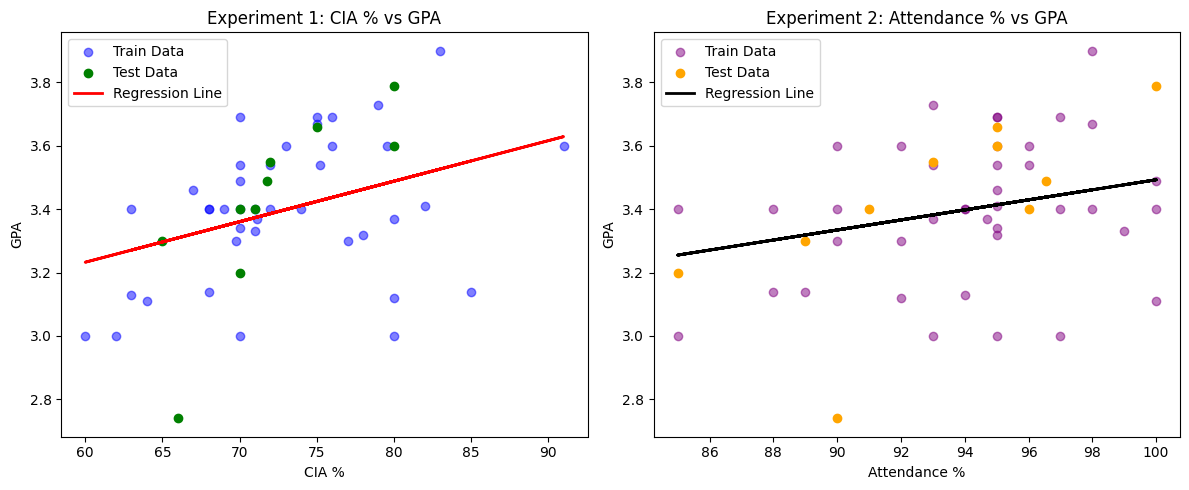

In [19]:
plt.figure(figsize=(12, 5))

# Experiment 1 plot
plt.subplot(1, 2, 1)
plt.scatter(X1_train, y1_train, color='blue', alpha=0.5, label='Train Data')
plt.scatter(X1_test, y1_test, color='green', label='Test Data')
plt.plot(X1_train, m_sk1 * X1_train + c_sk1, color='red', linewidth=2, label='Regression Line')
plt.title('Experiment 1: CIA % vs GPA')
plt.xlabel('CIA %')
plt.ylabel('GPA')
plt.legend()

# Experiment 2 plot
plt.subplot(1, 2, 2)
plt.scatter(X2_train, y2_train, color='purple', alpha=0.5, label='Train Data')
plt.scatter(X2_test, y2_test, color='orange', label='Test Data')
plt.plot(X2_train, m_sk2 * X2_train + c_sk2, color='black', linewidth=2, label='Regression Line')
plt.title('Experiment 2: Attendance % vs GPA')
plt.xlabel('Attendance %')
plt.ylabel('GPA')
plt.legend()

plt.tight_layout()
plt.savefig("plots/regression_plots.png")
plt.show()

---
## Parameter Saving Task

In [20]:
# 1. Save parameters (weights) of both experiments using Pickle
weights_dict = {
    'Experiment_1': {
        'slope': m_sk1,
        'intercept': c_sk1
    },
    'Experiment_2': {
        'slope': m_sk2,
        'intercept': c_sk2
    }
}

pickle_file_path = "linear_regression_weights.pkl"
with open(pickle_file_path, "wb") as file:
    pickle.dump(weights_dict, file)

print(f"Parameters successfully saved to {pickle_file_path}")

Parameters successfully saved to linear_regression_weights.pkl


In [21]:
# 2. Load the Pickle file
with open(pickle_file_path, "rb") as file:
    loaded_weights = pickle.load(file)

print("Loaded parameters from file:")
print(loaded_weights)

Loaded parameters from file:
{'Experiment_1': {'slope': np.float64(0.012783144582063031), 'intercept': np.float64(2.4655814552535955)}, 'Experiment_2': {'slope': np.float64(0.01584458075099674), 'intercept': np.float64(1.9083321292431645)}}


In [22]:
# 3. Demonstrate using loaded parameters for prediction
sample_cia = 80.0
sample_attendance = 95.0

# Load weights
exp1_slope = loaded_weights['Experiment_1']['slope']
exp1_intercept = loaded_weights['Experiment_1']['intercept']

exp2_slope = loaded_weights['Experiment_2']['slope']
exp2_intercept = loaded_weights['Experiment_2']['intercept']

# Predict manually using loaded weights
predicted_gpa_cia = (sample_cia * exp1_slope) + exp1_intercept
predicted_gpa_att = (sample_attendance * exp2_slope) + exp2_intercept

print(f"--- Sample Predictions ---")
print(f"For CIA = {sample_cia}%, predicted GPA is: {predicted_gpa_cia:.4f}")
print(f"For Attendance = {sample_attendance}%, predicted GPA is: {predicted_gpa_att:.4f}")

--- Sample Predictions ---
For CIA = 80.0%, predicted GPA is: 3.4882
For Attendance = 95.0%, predicted GPA is: 3.4136


---
## Final Observations & Inference

1. **Mathematical Equivalence:** The slope and intercept derived from the Scikit-Learn library and manually using Ordinary Least Squares (OLS) mathematical equations are **identical** (up to standard machine precision difference of $< 10^{-15}$). This shows that Scikit-Learn's `LinearRegression` implements OLS behind the scenes.
2. **Experiment 1 (CIA % vs GPA):** The positive slope indicates that a higher CIA percentage generally correlates with a higher GPA. This shows that continuous internal assessment performance is a positive predictor of the final GPA.
3. **Experiment 2 (Attendance % vs GPA):** The positive slope shows a positive relationship between class attendance and GPA. Higher attendance correlates with better academic performance.
4. **Parameter Saving:** Saving model parameters using `pickle` makes it possible to reload the weights later and make predictions on new student data without needing to retrain the model.